<a href="https://colab.research.google.com/github/alimugasa/NFL/blob/main/NYC_311_Operations_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NYC 311 Operations Bottleneck Analysis

**Role fit:** Operations Analyst  

**Business question:** Which service request categories, agencies, and boroughs are driving the most volume and the slowest resolution times, and where are the main operational bottlenecks?

**Data source:** This notebook uses the official NYC Open Data dataset **311 Service Requests from 2020 to Present** (dataset ID `erm2-nwe9`) through the CSV API endpoint. The dataset listing includes fields such as `unique_key`, `created_date`, `closed_date`, `agency`, `agency_name`, `complaint_type`, `descriptor`, `borough`, and `status`. The Socrata docs show that CSV is a supported API format, that SoQL is the query language used on these endpoints, and that `date_trunc_ym(...)` can be used to aggregate floating timestamps by month. :contentReference[oaicite:0]{index=0}

**Approach:** To keep the notebook fast in Google Colab while still using live public data, this project uses:
- full-period API aggregate queries for volume, complaint mix, borough demand, and backlog metrics
- a capped raw sample of up to **4,000 requests per month** for the last **12 calendar months** to analyze resolution time

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

In [29]:
# Official NYC Open Data CSV endpoint
BASE_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"

# We will analyze the current month plus the previous 11 full months
today = pd.Timestamp.today().normalize()
analysis_end = today + pd.Timedelta(days=1)
analysis_start = today.replace(day=1) - pd.DateOffset(months=11)

analysis_start_str = analysis_start.strftime("%Y-%m-%dT00:00:00")
analysis_end_str = analysis_end.strftime("%Y-%m-%dT00:00:00")

date_filter = f"created_date >= '{analysis_start_str}' AND created_date < '{analysis_end_str}'"

session = requests.Session()

def fetch_csv(params):
    """
    Run a SoQL query against the official CSV endpoint and return a DataFrame.
    """
    response = session.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()

    if not response.text.strip():
        return pd.DataFrame()

    return pd.read_csv(StringIO(response.text))


# ------------------------------------------------------------
# 1) Full-period aggregate pulls for operational volume metrics
# ------------------------------------------------------------
total_requests_df = fetch_csv({
    "$select": "count(*) as total_requests",
    "$where": date_filter
})

status_counts_df = fetch_csv({
    "$select": "status, count(*) as request_count",
    "$where": date_filter,
    "$group": "status",
    "$order": "request_count DESC"
})

monthly_volume_df = fetch_csv({
    "$select": "date_trunc_ym(created_date) as month, count(*) as request_count",
    "$where": date_filter,
    "$group": "month",
    "$order": "month"
})

complaint_counts_df = fetch_csv({
    "$select": "complaint_type, count(*) as request_count",
    "$where": date_filter,
    "$group": "complaint_type",
    "$order": "request_count DESC",
    "$limit": 10
})

borough_counts_df = fetch_csv({
    "$select": "borough, count(*) as request_count",
    "$where": date_filter,
    "$group": "borough",
    "$order": "request_count DESC"
})


# ------------------------------------------------------------
# 2) Capped raw pull for resolution-time analysis
#    We sample up to 4,000 rows per month to keep the notebook fast
# ------------------------------------------------------------
columns = [
    "unique_key", "created_date", "closed_date", "agency", "agency_name",
    "complaint_type", "descriptor", "borough", "status"
]

monthly_limit = 4000
month_starts = pd.date_range(start=analysis_start, periods=12, freq="MS")

raw_frames = []

for i, month_start in enumerate(month_starts):
    if i < len(month_starts) - 1:
        month_end = month_starts[i + 1]
    else:
        month_end = analysis_end

    month_filter = (
        f"created_date >= '{month_start.strftime('%Y-%m-%dT00:00:00')}' "
        f"AND created_date < '{month_end.strftime('%Y-%m-%dT00:00:00')}'"
    )

    month_df = fetch_csv({
        "$select": ",".join(columns),
        "$where": month_filter,
        "$order": "created_date DESC",
        "$limit": monthly_limit
    })

    if not month_df.empty:
        month_df["sample_month"] = month_start.strftime("%Y-%m")
        raw_frames.append(month_df)

    print(f"{month_start.strftime('%Y-%m')}: {len(month_df):,} rows pulled")

raw_df = pd.concat(raw_frames, ignore_index=True) if raw_frames else pd.DataFrame(columns=columns + ["sample_month"])

print("\nAnalysis window:")
print(f"Start: {analysis_start.date()}")
print(f"End:   {(analysis_end - pd.Timedelta(days=1)).date()}")
print(f"\nRaw resolution sample size: {len(raw_df):,} rows")

raw_df.head()

2025-04: 4,000 rows pulled
2025-05: 4,000 rows pulled
2025-06: 4,000 rows pulled
2025-07: 4,000 rows pulled
2025-08: 4,000 rows pulled
2025-09: 4,000 rows pulled
2025-10: 4,000 rows pulled
2025-11: 4,000 rows pulled
2025-12: 4,000 rows pulled
2026-01: 4,000 rows pulled
2026-02: 4,000 rows pulled
2026-03: 4,000 rows pulled

Analysis window:
Start: 2025-04-01
End:   2026-03-12

Raw resolution sample size: 48,000 rows


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,borough,status,sample_month
0,64805598,2025-04-30T23:59:55.000,2025-05-01T01:25:07.000,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,BRONX,Closed,2025-04
1,64809246,2025-04-30T23:59:47.000,2025-05-01T00:49:48.000,NYPD,New York City Police Department,Noise - Commercial,Loud Talking,QUEENS,Closed,2025-04
2,64806271,2025-04-30T23:59:46.000,2025-05-01T06:11:47.000,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,BRONX,Closed,2025-04
3,64810175,2025-04-30T23:59:39.000,NaN,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,MANHATTAN,Closed,2025-04
4,64807810,2025-04-30T23:59:22.000,2025-05-01T01:56:35.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,Closed,2025-04


In [30]:
# -----------------------------
# Clean aggregate query outputs
# -----------------------------
total_requests = int(pd.to_numeric(total_requests_df.loc[0, "total_requests"], errors="coerce"))

status_counts_df["status"] = status_counts_df["status"].fillna("Unknown").astype(str).str.strip()
status_counts_df["status"] = status_counts_df["status"].replace({"": "Unknown", "N/A": "Unknown"})
status_counts_df["request_count"] = pd.to_numeric(status_counts_df["request_count"], errors="coerce").fillna(0).astype(int)

monthly_volume_df["month"] = pd.to_datetime(monthly_volume_df["month"], errors="coerce")
monthly_volume_df["request_count"] = pd.to_numeric(monthly_volume_df["request_count"], errors="coerce").fillna(0).astype(int)
monthly_volume_df = monthly_volume_df.dropna(subset=["month"]).sort_values("month")

complaint_counts_df["complaint_type"] = complaint_counts_df["complaint_type"].fillna("Unknown").astype(str).str.strip()
complaint_counts_df["complaint_type"] = complaint_counts_df["complaint_type"].replace({"": "Unknown", "N/A": "Unknown"})
complaint_counts_df["request_count"] = pd.to_numeric(complaint_counts_df["request_count"], errors="coerce").fillna(0).astype(int)

borough_counts_df["borough"] = borough_counts_df["borough"].fillna("Unknown").astype(str).str.strip()
borough_counts_df["borough"] = borough_counts_df["borough"].replace({"": "Unknown", "N/A": "Unknown"})
borough_counts_df["request_count"] = pd.to_numeric(borough_counts_df["request_count"], errors="coerce").fillna(0).astype(int)


# -----------------------------
# Clean raw sample
# -----------------------------
raw_df = raw_df[columns + ["sample_month"]].copy()

raw_df["created_date"] = pd.to_datetime(raw_df["created_date"], errors="coerce")
raw_df["closed_date"] = pd.to_datetime(raw_df["closed_date"], errors="coerce")

# Only drop rows that cannot support time-based analysis
raw_df = raw_df.dropna(subset=["created_date"]).copy()

# Remove duplicate service request IDs if any exist
raw_df = raw_df.drop_duplicates(subset=["unique_key"]).copy()

# Keep open requests in the dataset because they are useful for operations reporting
text_cols = ["agency", "agency_name", "complaint_type", "descriptor", "borough", "status"]
for col in text_cols:
    raw_df[col] = raw_df[col].fillna("Unknown").astype(str).str.strip()
    raw_df[col] = raw_df[col].replace({"": "Unknown", "N/A": "Unknown"})

# Use the short agency code if agency_name is missing
raw_df["agency_name"] = np.where(raw_df["agency_name"] == "Unknown", raw_df["agency"], raw_df["agency_name"])

print("Raw sample rows after cleaning:", f"{len(raw_df):,}")
print("\nRaw sample rows by month:")
print(raw_df["sample_month"].value_counts().sort_index())

raw_df.head()

Raw sample rows after cleaning: 48,000

Raw sample rows by month:
sample_month
2025-04    4000
2025-05    4000
2025-06    4000
2025-07    4000
2025-08    4000
2025-09    4000
2025-10    4000
2025-11    4000
2025-12    4000
2026-01    4000
2026-02    4000
2026-03    4000
Name: count, dtype: int64


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,borough,status,sample_month
0,64805598,2025-04-30 23:59:55,2025-05-01 01:25:07,NYPD,New York City Police Department,Noise - Residential,Banging/Pounding,BRONX,Closed,2025-04
1,64809246,2025-04-30 23:59:47,2025-05-01 00:49:48,NYPD,New York City Police Department,Noise - Commercial,Loud Talking,QUEENS,Closed,2025-04
2,64806271,2025-04-30 23:59:46,2025-05-01 06:11:47,NYPD,New York City Police Department,Illegal Parking,Blocked Hydrant,BRONX,Closed,2025-04
3,64810175,2025-04-30 23:59:39,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,Unknown,MANHATTAN,Closed,2025-04
4,64807810,2025-04-30 23:59:22,2025-05-01 01:56:35,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,Closed,2025-04


In [31]:
# Group all non-Closed statuses into a simple Open / Closed view for backlog tracking
status_counts_df["status_group"] = np.where(
    status_counts_df["status"].str.lower().eq("closed"),
    "Closed",
    "Open"
)

status_summary = (
    status_counts_df.groupby("status_group", as_index=False)["request_count"]
    .sum()
)

status_summary = (
    status_summary.set_index("status_group")
    .reindex(["Open", "Closed"])
    .fillna(0)
    .astype(int)
    .reset_index()
)

closed_requests = int(status_summary.loc[status_summary["status_group"] == "Closed", "request_count"].iloc[0])
open_requests = int(status_summary.loc[status_summary["status_group"] == "Open", "request_count"].iloc[0])
open_request_rate = open_requests / total_requests if total_requests else np.nan


# Resolution time in hours for raw sample rows
raw_df["status_group"] = np.where(
    raw_df["closed_date"].notna() | raw_df["status"].str.lower().eq("closed"),
    "Closed",
    "Open"
)

raw_df["resolution_hours"] = (
    (raw_df["closed_date"] - raw_df["created_date"]).dt.total_seconds() / 3600
)

# Use only valid closed requests for resolution analysis
closed_df = raw_df[
    (raw_df["status_group"] == "Closed") &
    (raw_df["resolution_hours"].notna()) &
    (raw_df["resolution_hours"] >= 0)
].copy()

# Median is more stable than mean for service-request cycle times
median_resolution_hours = round(closed_df["resolution_hours"].median(), 2)

# Set minimum case counts so tiny groups do not dominate the "slowest" lists
min_agency_cases = 100
min_complaint_cases = 100

agency_resolution_df = (
    closed_df.groupby("agency_name", as_index=False)
    .agg(
        closed_requests=("unique_key", "count"),
        median_resolution_hours=("resolution_hours", "median")
    )
)

agency_resolution_df = (
    agency_resolution_df[agency_resolution_df["closed_requests"] >= min_agency_cases]
    .sort_values("median_resolution_hours", ascending=False)
    .head(10)
    .copy()
)

agency_resolution_df["median_resolution_hours"] = agency_resolution_df["median_resolution_hours"].round(2)

complaint_resolution_df = (
    closed_df.groupby("complaint_type", as_index=False)
    .agg(
        closed_requests=("unique_key", "count"),
        median_resolution_hours=("resolution_hours", "median")
    )
)

complaint_resolution_df = (
    complaint_resolution_df[complaint_resolution_df["closed_requests"] >= min_complaint_cases]
    .sort_values("median_resolution_hours", ascending=False)
    .head(10)
    .copy()
)

complaint_resolution_df["median_resolution_hours"] = complaint_resolution_df["median_resolution_hours"].round(2)

print("Closed sample rows used for resolution analysis:", f"{len(closed_df):,}")
print("Overall median resolution time (hours):", median_resolution_hours)

Closed sample rows used for resolution analysis: 43,916
Overall median resolution time (hours): 3.1


In [32]:
kpi_df = pd.DataFrame({
    "KPI": [
        "Total requests (last 12 calendar months)",
        "Closed requests",
        "Open / not closed requests",
        "Open request rate",
        "Median resolution time in raw sample (hours)"
    ],
    "Value": [
        f"{total_requests:,}",
        f"{closed_requests:,}",
        f"{open_requests:,}",
        f"{open_request_rate:.1%}",
        f"{median_resolution_hours:,.2f}"
    ]
})

print("Operations KPI Summary")
kpi_df

Operations KPI Summary


,KPI,Value
0,Total requests (last 12 calendar months),"3,554,007"
1,Closed requests,"3,366,252"
2,Open / not closed requests,"187,755"
3,Open request rate,5.3%
4,Median resolution time in raw sample (hours),3.10


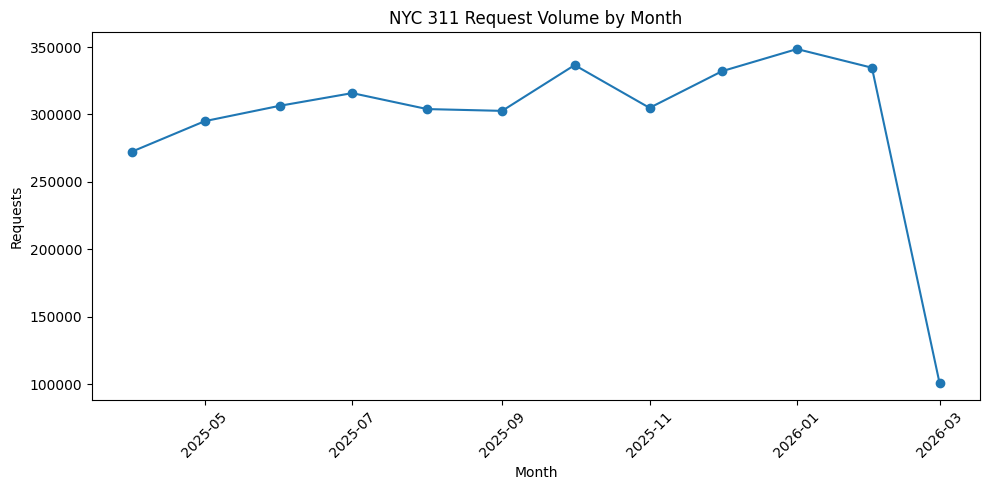

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_volume_df["month"], monthly_volume_df["request_count"], marker="o")

plt.title("NYC 311 Request Volume by Month")
plt.xlabel("Month")
plt.ylabel("Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

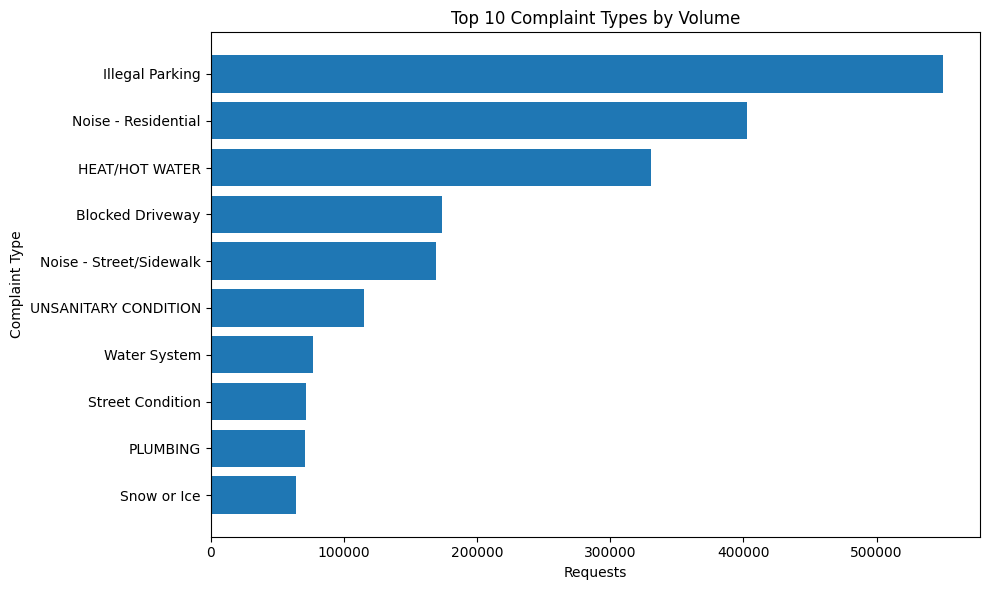

,complaint_type,request_count
0,Illegal Parking,550086
1,Noise - Residential,402918
2,HEAT/HOT WATER,330504
3,Blocked Driveway,173685
4,Noise - Street/Sidewalk,168979
5,UNSANITARY CONDITION,115374
6,Water System,77283
7,Street Condition,71587
8,PLUMBING,71140
9,Snow or Ice,63928


In [34]:
top_complaints_plot = complaint_counts_df.sort_values("request_count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_complaints_plot["complaint_type"], top_complaints_plot["request_count"])

plt.title("Top 10 Complaint Types by Volume")
plt.xlabel("Requests")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

complaint_counts_df.reset_index(drop=True)

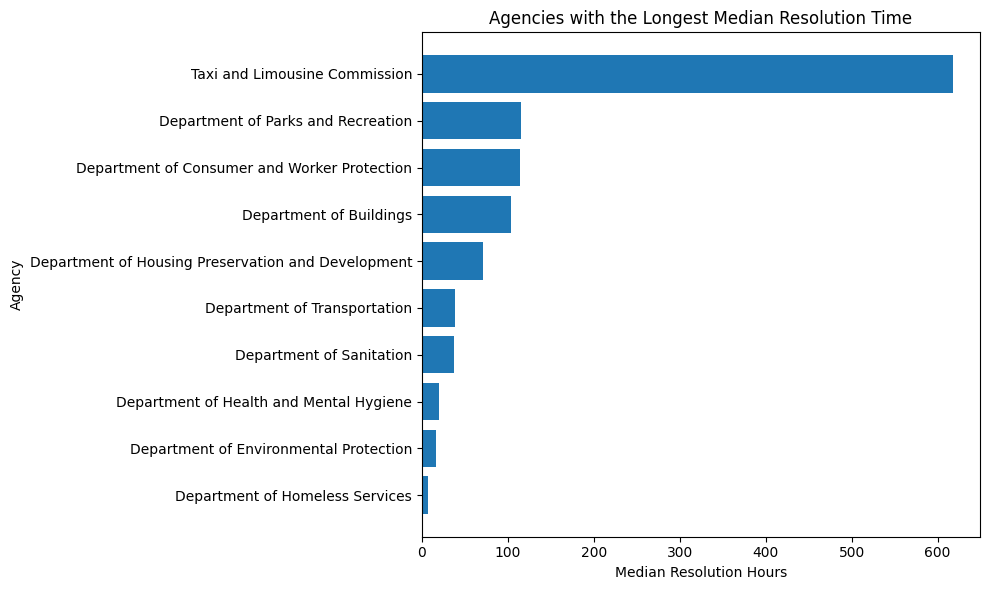

In [35]:
agency_plot = agency_resolution_df.sort_values("median_resolution_hours", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(agency_plot["agency_name"], agency_plot["median_resolution_hours"])

plt.title("Agencies with the Longest Median Resolution Time")
plt.xlabel("Median Resolution Hours")
plt.ylabel("Agency")
plt.tight_layout()
plt.show()

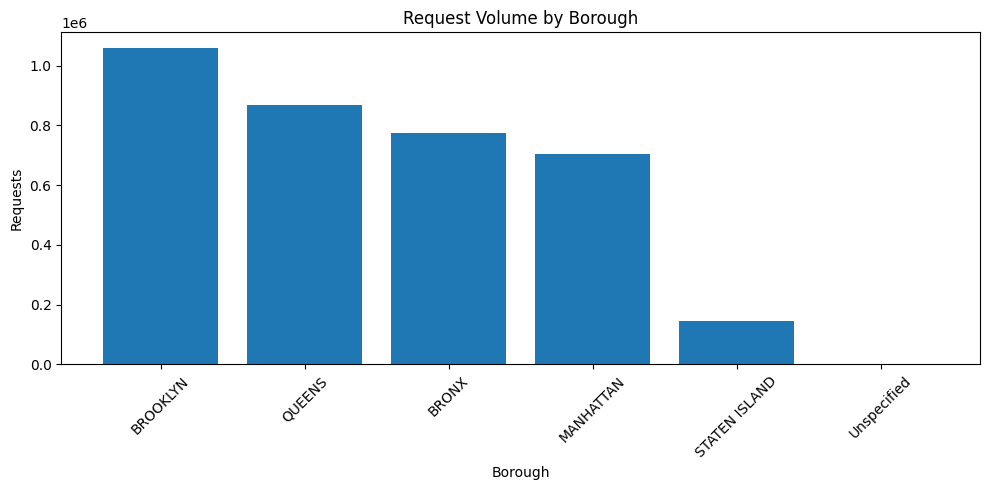

,borough,request_count
0,BROOKLYN,1058769
1,QUEENS,867413
2,BRONX,775206
3,MANHATTAN,705880
4,STATEN ISLAND,144141
5,Unspecified,2598


In [36]:
borough_plot = borough_counts_df.sort_values("request_count", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(borough_plot["borough"], borough_plot["request_count"])

plt.title("Request Volume by Borough")
plt.xlabel("Borough")
plt.ylabel("Requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

borough_counts_df.reset_index(drop=True)

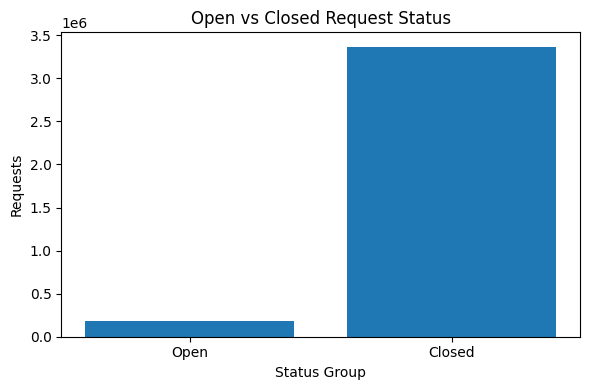

,status_group,request_count
0,Open,187755
1,Closed,3366252


In [37]:
plt.figure(figsize=(6, 4))
plt.bar(status_summary["status_group"], status_summary["request_count"])

plt.title("Open vs Closed Request Status")
plt.xlabel("Status Group")
plt.ylabel("Requests")
plt.tight_layout()
plt.show()

status_summary

In [38]:
print(f"Agencies with the longest median resolution time (minimum {min_agency_cases} closed sample requests)")
agency_resolution_df.reset_index(drop=True)

Agencies with the longest median resolution time (minimum 100 closed sample requests)


,agency_name,closed_requests,median_resolution_hours
0,Taxi and Limousine Commission,238,618.34
1,Department of Parks and Recreation,953,114.73
2,Department of Consumer and Worker Protection,182,114.31
3,Department of Buildings,1097,103.59
4,Department of Housing Preservation and Develop...,7794,71.60
5,Department of Transportation,1971,38.52
6,Department of Sanitation,2604,37.32
7,Department of Health and Mental Hygiene,741,19.73
8,Department of Environmental Protection,2413,16.57
9,Department of Homeless Services,349,6.97


In [39]:
print(f"Common complaint types with the longest median resolution time (minimum {min_complaint_cases} closed sample requests)")
complaint_resolution_df.reset_index(drop=True)

Common complaint types with the longest median resolution time (minimum 100 closed sample requests)


,complaint_type,closed_requests,median_resolution_hours
0,Food Establishment,121,1440.11
1,Building/Use,212,1107.68
2,For Hire Vehicle Complaint,138,837.96
3,APPLIANCE,158,330.03
4,Overgrown Tree/Branches,119,303.17
5,GENERAL,236,247.31
6,WATER LEAK,431,218.81
7,UNSANITARY CONDITION,950,191.48
8,DOOR/WINDOW,352,188.99
9,Maintenance or Facility,177,186.46
